# Prototype A — PEMFC 산소 방정식에서 $D_{eff}(s)$ 학습

**목적: 물리 발견이 아니라 adjoint 배선 검증.**

PEMFC 전체(3필드, 순전파 48분)로 바로 가면 학습 실패 시 원인이 최소 네 가지다.
이 노트북은 그중 셋을 구조적으로 제거하고 **"adjoint를 제대로 연결했는가"** 하나만 남긴다.

| | PEMFC 본체 | Prototype A |
|---|---|---|
| 미지수 | $p,\ C_w,\ C_g^{O_2}$ (mixed) | **$C_g^{O_2}$ 하나** |
| 포화도 $s$ | $C_w$의 함수 (해에 의존) | **미리 정한 고정 필드** |
| 격자 | 24×60 | 12×30 |
| $\eta$ | continuation 1.5까지 | **막 플럭스 직접 지정** |
| box 제약 | `vinewtonrsls` | 없음 |
| 순전파 | ~48 min | **< 1 s** |

$s$를 고정하면 $D_{eff}=\mathcal G_\theta(s)$가 미지수 $C$에 의존하지 않는다. 따라서

- 순전파가 **선형** (Newton 불필요)
- Case 4에서 손유도했던 **tangent 보정항 $K_{corr}$이 아예 없음**
- adjoint가 $K^\top\psi = \partial J/\partial C$ 하나로 끝남

가장 순수한 형태로 배선만 시험하는 구성이다.

**성공 판정의 1순위는 학습 결과가 아니라 §5의 그래디언트 검증이다.**

## Cell 1 — 환경 (DOLFINx 0.10 + micromamba)

FEML 노트북과 동일. Drive를 패키지 캐시로 쓰므로 첫 실행 5–10분, 이후 30초.

In [1]:
from google.colab import drive
import os, subprocess
from pathlib import Path

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print('Google Drive already mounted')

REPO_URL = 'https://github.com/SeoulTechPSE/fenicsx-colab.git'
REPO_DIR  = Path('/content/fenicsx-colab')
if not REPO_DIR.exists():
    subprocess.run(['git','clone',REPO_URL,str(REPO_DIR)], check=True)
    print('Cloned SeoulTechPSE/fenicsx-colab')
else:
    subprocess.run(['git','-C',str(REPO_DIR),'pull','--quiet'])
    print('fenicsx-colab up to date')

# MPI host-file (single process for Colab)
N_PROC = 1
with open('/root/hostfile','w') as f:
    f.write(f'localhost slots={N_PROC}\n')
os.environ['OMPI_MCA_rmaps_default_mapping_policy'] = 'slot:OVERSUBSCRIBE'
os.environ['PRTE_MCA_rmaps_default_mapping_policy'] = 'slot:OVERSUBSCRIBE'

# Install DOLFINx 0.10 via micromamba + conda-forge
%run {REPO_DIR/'setup_fenicsx.py'} --version 0.10

Mounted at /content/drive
Cloned SeoulTechPSE/fenicsx-colab
🔧 FEniCSx Setup Configuration
DOLFINx version : 0.10
PETSc type      : real
Env name        : fenicsx
Clean install   : False

📦 Google Drive detected — using persistent cache

🔧 Installing FEniCSx environment...

🔍 Verifying installation...
✅ Installed: DOLFINx 0.10.0
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered (env: fenicsx)

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: DOLFINx 0.10 is installed in env 'fenicsx'
   - Real PETSc: recommended for most FEM problems
   - For complex problems, reinstall with --complex


## Cell 2 — PyTorch 설치

`--extra-index-url`로 CPU 빌드를 받는다. Prototype A는 external-operator를 쓰지 않으므로 PyTorch만 있으면 된다.

In [2]:
import subprocess
ENV    = 'fenicsx'
PYTHON = f'/content/micromamba/envs/{ENV}/bin/python'

def env_pip(*pkgs, no_deps=False, extra_index=None):
    """Use conda env python -m pip directly (bypasses micromamba run)."""
    cmd = [PYTHON, '-m', 'pip', 'install', '--quiet'] + list(pkgs)
    if no_deps:     cmd.append('--no-deps')
    if extra_index: cmd += ['--extra-index-url', extra_index]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print('STDERR:', r.stderr[-400:])
    return r.returncode == 0

r = subprocess.run([PYTHON,'-m','pip','--version'], capture_output=True, text=True)
if r.returncode != 0:
    print('pip not found -> installing via ensurepip...')
    subprocess.run([PYTHON,'-m','ensurepip','--upgrade'], capture_output=True)
    subprocess.run([PYTHON,'-m','pip','install','--upgrade','pip','--quiet'],
                   capture_output=True)
print('pip:', subprocess.run([PYTHON,'-m','pip','--version'],
    capture_output=True, text=True).stdout.strip())

print('\nInstalling PyTorch CPU ...')
ok = env_pip('torch', extra_index='https://download.pytorch.org/whl/cpu')
if not ok:
    ok = env_pip('torch')
print('OK PyTorch' if ok else 'FAILED PyTorch')

import os
r = subprocess.run(
    [PYTHON,'-c',
     'import site; sp=[p for p in site.getsitepackages() if "fenicsx" in p]; '
     'print(sp[0] if sp else "?")'],
    capture_output=True, text=True)
sp = r.stdout.strip()
print(f'\nsite-packages: {sp}')
print(f'  {"OK" if os.path.exists(os.path.join(sp,"torch")) else "MISSING"} torch')
print('\n(DOLFINx must be imported inside %%fenicsx cells only - GLIBCXX constraint)')

pip not found -> installing via ensurepip...
pip: pip 26.2.1 from /content/micromamba/envs/fenicsx/lib/python3.14/site-packages/pip (python 3.14)

Installing PyTorch CPU ...
OK PyTorch

site-packages: /content/micromamba/envs/fenicsx/lib/python3.14/site-packages
  OK torch

(DOLFINx must be imported inside %%fenicsx cells only - GLIBCXX constraint)


## Cell 3 — `%%fenicsx` 매직 등록

In [3]:
from pathlib import Path
import os

REPO_DIR = Path('/content/fenicsx-colab')
MAGIC_FILE = REPO_DIR / 'magic' / 'fenicsx_magic.py'

if MAGIC_FILE.exists():
    os.environ['FENICSX_ENV_NAME'] = 'fenicsx'
    os.environ['OMPI_ALLOW_RUN_AS_ROOT'] = '1'
    os.environ['OMPI_ALLOW_RUN_AS_ROOT_CONFIRM'] = '1'
    exec(compile(MAGIC_FILE.read_text(), str(MAGIC_FILE), 'exec'), globals())
    print('%%fenicsx magic registered (env: fenicsx)')
else:
    print('magic file not found - re-run Cell 1')

%%fenicsx magic registered (env: fenicsx)


In [4]:
%%fenicsx
import dolfinx, sys, torch
print(f'Python  : {sys.version.split()[0]}')
print(f'DOLFINx : {dolfinx.__version__}')
print(f'PyTorch : {torch.__version__}')
print('%%fenicsx magic working')

Python  : 3.14.6
DOLFINx : 0.10.0
PyTorch : 2.13.0+cpu
%%fenicsx magic working


## Cell 4 — 문제 정의

### 물리

PEMFC 산소 방정식(Chang Eq. 26 / PEMFC 코드 `F_oxy`)을 $s$ 고정 조건에서 그대로 쓴다.

$$
\underbrace{\nabla\cdot(D_{eff}\nabla C)}_{\text{확산}}
-\underbrace{\nabla\cdot(C\,\mathbf W_{O_2})}_{\text{기상 대류}}
+\underbrace{\nabla\cdot(C\,\mathbf j_l)}_{\text{액상 모세관 배제}} = 0
$$

경계조건은 PEMFC와 동일한 4종:

| 경계 | 위치 | 조건 |
|---|---|---|
| membrane | $x=0$ | Neumann — 산소 소비 $N_{O_2}$ |
| inlet | $x=L_x,\ y\le 0.4$mm | **Dirichlet** $C=Y_{O_2,in}$ |
| rib | $x=L_x,\ 0.4<y\le1.6$mm | 자연 무플럭스 |
| outlet | $x=L_x,\ y>1.6$mm | 대류 유출 (upwind) |

> **Dirichlet이 반드시 하나는 있어야 한다.** 전부 Neumann이면 $\mathcal G_\theta$ 전체에 상수를
> 곱하고 $\nabla C$를 그만큼 나눠도 같은 플럭스가 나온다 — 곡선 모양은 맞는데 **배율이
> 결정되지 않는다**. 유입구 Dirichlet이 이 자유도를 없앤다.

### 학습 대상

$$
D_{eff} = \rho_g\,\underbrace{[\varepsilon(1-s)]^{\tau}}_{\text{정답},\ \tau=1.5}\,D_g^{O_2}
\quad\longrightarrow\quad
D_{eff} = \rho_g\,\underbrace{\mathcal G_\theta(s)}_{\text{신경망}}\,D_g^{O_2}
$$

### 압력은 학습 사슬 밖에 있다

$\kappa = \rho_{mix}K/\mu_{mix}$는 $s$에만 의존하고 $\mathcal G_\theta$와 무관하다.
따라서 **Darcy 압력장은 샘플마다 한 번만 풀어 고정**하면 되고, $\theta$에 대한 미분에
전혀 관여하지 않는다. 산소 방정식이 $C$에 대해 **선형**이 되는 이유다.

### 식별 가능성 설계

Case 4가 내부 열원 $f(x)$를 넣어 $T(x)$를 비단조로 만든 것과 같은 논리를 쓴다.
여기서는 **$s$ 필드 자체를 샘플마다 바꾼다** — 같은 $s$ 값이 서로 다른 위치에서
서로 다른 $\nabla C$와 함께 관측되므로, $\mathcal G_\theta(s)$의 각 구간이 독립적으로 제약된다.

샘플 = (3가지 $s$ 필드) × (3가지 막 플럭스 세기) = 9개, 그중 6개 train / 3개 test.

## Cell 5 — 메인 셀이 하는 일

```
① 형상·배경필드   도메인, facet tag 4종, s(x,y) 지정, Darcy 압력 1회 풀이
② 정답 데이터     tau=1.5로 산소 방정식 풀이 → 잡음 2% → 관측
③ 신경망          G_theta(s), Softplus 출력(양수 보장), 초기값 eps^1.5
④ 순전파          NN 값 → quadrature Function → 선형계 1회
⑤ adjoint         K^T psi = dJ/dC   (solveTranspose)
⑥ VJP             dJ/dDeff = -w_qp * (grad C . grad psi)  → backward()
⑦ 검증            ★ 유한차분 대조 (학습 전 필수 관문)
⑧ 학습            Adam + 조기종료
```

**⑦이 이 노트북의 존재 이유다.** 통과하지 못하면 ⑧을 돌릴 이유가 없다.

### VJP 유도 (부호 포함)

잔차 $F(C;D_{eff})=0$을 $\theta$로 미분하면 $K\,\partial C/\partial\theta = -\partial F/\partial\theta$.
$\psi$를 $K^\top\psi = (\partial J/\partial C)^\top$로 정의하면

$$
\frac{dJ}{d\theta} = -\psi^\top\frac{\partial F}{\partial D_{eff}}\frac{\partial D_{eff}}{\partial\theta}
$$

잔차에서 $D_{eff}$가 등장하는 항은 $\int D_{eff}\nabla C\cdot\nabla v\,dx$ 하나뿐이므로

$$
\boxed{\ \frac{dJ}{dD_{eff}}\bigg|_{qp} = -\,w_{qp}\,(\nabla C\cdot\nabla\psi)_{qp}\ }
$$

$w_{qp}$는 적분점 가중치. Case 4는 이 자리에 $1/N_{qp}$를 썼는데(균일 격자에서만 타당),
여기서는 $\int 1\cdot v_Q\,dx$를 조립해 **정확한 가중치**를 쓴다 — 그래야 ⑦이 기계정밀도로 통과한다.

In [11]:
%%fenicsx
import os, time, json
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc
import ufl, basix
from dolfinx import mesh, fem
from dolfinx.fem import petsc as fem_petsc
from ufl import grad, inner, Measure
import torch, torch.nn as nn

torch.manual_seed(0); np.random.seed(0)
torch.set_default_dtype(torch.float64)
comm = MPI.COMM_WORLD
OUT = '/content/protoA_results'; os.makedirs(OUT, exist_ok=True)

# =====================================================================
# 0. PARAMETERS  (PEMFC DEFAULT_PARAMS subset)
# =====================================================================
R, F_const = 8.314, 96485.0
T_cell   = 330.0
K_perm   = 1.2e-12
eps_p    = 0.30
Lx, w_ch, w_rb = 0.20e-3, 0.8e-3, 1.2e-3
Ly = w_ch + w_rb
y_in_end, y_rib_end = 0.5*w_ch, 0.5*w_ch + w_rb
p_in, p_out = 1.007e5, 1.0e5
mu_g, mu_l  = 2.03e-5, 3.15e-4
D_O2_g   = 1.775e-5
M_O2, M_N2, M_H2O = 0.032, 0.028, 0.018
rho_l    = 1000.0
sigma_st = 0.0625
theta_c  = np.deg2rad(91.0)
n_corey  = 3.0
X_O2_in  = 0.21
TAU_TRUE = 1.5                      # <-- ground truth exponent

M_mix_in = X_O2_in*M_O2 + (1-X_O2_in)*M_N2
Y_O2_in  = X_O2_in*M_O2/M_mix_in
I0, alpha_c = 100.0, 0.5
C_O2_ref = 40.0
rho_g    = p_out*M_mix_in/(R*T_cell)
G_REF    = eps_p**TAU_TRUE          # ~0.164, network output scale

nx, ny, qdeg = 12, 30, 2

# =====================================================================
# 1. MESH, TAGS, SPACES
# =====================================================================
domain = mesh.create_rectangle(comm, [[0.,0.],[Lx,Ly]], [nx,ny], mesh.CellType.triangle)
V = fem.functionspace(domain, ('Lagrange', 1))
Qe = basix.ufl.quadrature_element(domain.topology.cell_name(), degree=qdeg, value_shape=())
Q  = fem.functionspace(domain, Qe)
Ve = basix.ufl.quadrature_element(domain.topology.cell_name(), degree=qdeg, value_shape=(2,))
QV = fem.functionspace(domain, Ve)
dx = Measure('dx', domain=domain,
             metadata={'quadrature_scheme':'default','quadrature_degree':qdeg})

TAG_MEM, TAG_IN, TAG_RIB, TAG_OUT = 1, 2, 3, 4
def on_mem(x): return np.isclose(x[0], 0.0)
def on_in(x):  return np.isclose(x[0], Lx) & (x[1] <= y_in_end + 1e-12)
def on_rib(x): return np.isclose(x[0], Lx) & (x[1] > y_in_end+1e-12) & (x[1] <= y_rib_end+1e-12)
def on_out(x): return np.isclose(x[0], Lx) & (x[1] > y_rib_end + 1e-12)

fdim = domain.topology.dim - 1
facets, marks = [], []
for tag, fn in [(TAG_MEM,on_mem),(TAG_IN,on_in),(TAG_RIB,on_rib),(TAG_OUT,on_out)]:
    f = mesh.locate_entities_boundary(domain, fdim, fn)
    facets.append(f); marks.append(np.full(len(f), tag, np.int32))
facets = np.hstack(facets); marks = np.hstack(marks)
order  = np.argsort(facets)
ftags  = mesh.meshtags(domain, fdim, facets[order], marks[order])
ds     = Measure('ds', domain=domain, subdomain_data=ftags,
                 metadata={'quadrature_degree':qdeg})
nvec   = ufl.FacetNormal(domain)

N_dof = V.dofmap.index_map.size_global
N_qp  = Q.dofmap.index_map.size_global
print(f'V dof: {N_dof} | Q (quadrature) dof: {N_qp}')

# quadrature weights: assemble  int(1 * v_Q) dx  -> exactly w_qp
_vQ = ufl.TestFunction(Q)
qw = fem_petsc.assemble_vector(fem.form(_vQ*dx)).getArray().copy()
print(f'quad weight  sum={qw.sum():.4e}  (domain area={Lx*Ly:.4e})')

# =====================================================================
# 2. PRESCRIBED SATURATION FIELDS  (identifiability by design)
# =====================================================================
qp_coords = Q.tabulate_dof_coordinates()[:, :2]   # NN input / Deff
v_coords  = V.tabulate_dof_coordinates()[:, :2]   # CG1 background fields

def s_field(coords, kind, amp):
    """Smooth prescribed saturation, evaluated at arbitrary coordinates.

    NOTE  s must live in CG1, NOT in the quadrature space: the capillary flux
    needs grad(s), and UFL cannot differentiate a Quadrature element
    ("Cannot take derivatives of Quadrature element").  The same applies to
    every coefficient appearing in a ds(...) facet integral.
    """
    xn = np.clip(coords[:,0]/Lx, 0.0, 1.0)
    yn = np.clip(coords[:,1]/Ly, 0.0, 1.0)   # guard fractional power at y=0
    if kind == 0:   shape = (1.0-xn)*(0.25+0.75*yn)
    elif kind == 1: shape = (1.0-xn)**2*(0.15+0.85*yn**0.6)
    else:           shape = (1.0-0.6*xn)*np.exp(-((yn-0.75)/0.45)**2)
    # each shape is analytically bounded by 1 -> no data-dependent rescaling,
    # so the CG1 and quadrature evaluations stay exactly consistent
    return amp*shape

# =====================================================================
# 3. FIXED CLOSURES (depend on s only -> outside the learning chain)
# =====================================================================
def fixed_fields(s_np):
    """rho_mix, kappa, gas convective velocity factor, capillary flux jl."""
    s = np.clip(s_np, 0.0, 0.99)
    rho_mix = rho_g*(1.0-s) + rho_l*s
    krl, krg = s**n_corey, (1.0-s)**n_corey
    lam_l = (krl/mu_l)/(krl/mu_l + krg/mu_g + 1e-30)
    lam_g = 1.0 - lam_l
    nu_mix = 1.0/(krg/(mu_g/rho_g) + krl/(mu_l/rho_l) + 1e-30)
    mu_mix = nu_mix*rho_mix
    kappa  = rho_mix*K_perm/(mu_mix + 1e-30)
    dJds   = 1.417 - 4.240*s + 3.789*s**2          # hydrophobic branch
    Dc = (lam_l*lam_g*K_perm/(nu_mix+1e-30))*sigma_st*np.cos(theta_c) \
         * (eps_p/K_perm)**0.5 * dJds
    return rho_mix, kappa, lam_g, Dc

def tafel_coeff(s_v, eta):
    s = np.clip(s_v, 0.0, 0.99)
    expfac = np.exp(alpha_c*F_const*eta/(R*T_cell))
    return (1.0-s)*I0*rho_g/(4.0*F_const*C_O2_ref)*expfac
# ---- containers reused every solve -------------------------------------
# Background closures -> CG1 (they need grad(.) and appear on facets)
s_fn    = fem.Function(V)
rho_fn  = fem.Function(V)
kap_fn  = fem.Function(V)
lamg_fn = fem.Function(V)
Dc_fn   = fem.Function(V)
# Only the LEARNED coefficient lives in the quadrature space (dx integrals only)
Deff_fn = fem.Function(Q)
tafel_fn = fem.Function(V)
N_O2_c  = fem.Constant(domain, PETSc.ScalarType(0.0))

# ---- pressure problem (linear, independent of theta) -------------------
p_tr, p_te = ufl.TrialFunction(V), ufl.TestFunction(V)
p_sol = fem.Function(V)
a_p = fem.form(kap_fn*inner(grad(p_tr), grad(p_te))*dx)
L_p = fem.form(N_O2_c*p_te*ds(TAG_MEM))     # net mass injection proxy

dofs_p_in  = fem.locate_dofs_geometrical(V, on_in)
dofs_p_out = fem.locate_dofs_geometrical(V, on_out)
bcs_p = [fem.dirichletbc(PETSc.ScalarType(p_in - p_out), dofs_p_in, V),
         fem.dirichletbc(PETSc.ScalarType(0.0),          dofs_p_out, V)]

def solve_pressure():
    A = fem_petsc.assemble_matrix(a_p, bcs=bcs_p); A.assemble()
    b = fem_petsc.assemble_vector(L_p)
    fem_petsc.apply_lifting(b, [a_p], [bcs_p]); b.ghostUpdate(
        addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    fem_petsc.set_bc(b, bcs_p)
    ksp = PETSc.KSP().create(comm); ksp.setOperators(A)
    ksp.setType('preonly'); ksp.getPC().setType('lu')
    ksp.solve(b, p_sol.x.petsc_vec); p_sol.x.scatter_forward()
    ksp.destroy(); A.destroy(); b.destroy()

# =====================================================================
# 4. OXYGEN PROBLEM  (linear in C once Deff is given)
# =====================================================================
C_tr, C_te = ufl.TrialFunction(V), ufl.TestFunction(V)
C_fn, psi_fn = fem.Function(V), fem.Function(V)

u_darcy = -(kap_fn/rho_fn)*grad(p_sol)
W_O2    = rho_fn*lamg_fn*u_darcy
Jl_vec  = Dc_fn*grad(s_fn)

def smooth_out(x, e=1e-5):
    return 0.5*(x + ufl.sqrt(x*x + e*e))

a_C = fem.form( Deff_fn*inner(grad(C_tr), grad(C_te))*dx
              - C_tr*inner(W_O2, grad(C_te))*dx
              + C_tr*inner(Jl_vec, grad(C_te))*dx
              + C_tr*smooth_out(inner(W_O2, nvec))*C_te*ds(TAG_OUT)
              + tafel_fn*C_tr*C_te*ds(TAG_MEM) )          # 추가된 한 줄
L_C = fem.form( fem.Constant(domain, PETSc.ScalarType(0.0))*C_te*dx )   # 동차로 변경

dofs_C_in = fem.locate_dofs_geometrical(V, on_in)
bcs_C = [fem.dirichletbc(PETSc.ScalarType(Y_O2_in), dofs_C_in, V)]
bc_rows = bcs_C[0].dof_indices()[0]

def assemble_oxygen():
    A = fem_petsc.assemble_matrix(a_C, bcs=bcs_C); A.assemble()
    b = fem_petsc.assemble_vector(L_C)
    fem_petsc.apply_lifting(b, [a_C], [bcs_C]); b.ghostUpdate(
        addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    fem_petsc.set_bc(b, bcs_C)
    return A, b

def solve_oxygen():
    A, b = assemble_oxygen()
    ksp = PETSc.KSP().create(comm); ksp.setOperators(A)
    ksp.setType('preonly'); ksp.getPC().setType('lu')
    ksp.solve(b, C_fn.x.petsc_vec); C_fn.x.scatter_forward()
    return A, ksp        # keep factorised A for the adjoint

def set_case(sm):
    """Load one sample: CG1 background fields + membrane flux magnitude."""
    rho_m, kap, lamg, Dc = fixed_fields(sm['s_v'])
    s_fn.x.array[:]    = sm['s_v']
    rho_fn.x.array[:]  = rho_m
    kap_fn.x.array[:]  = kap
    lamg_fn.x.array[:] = lamg
    Dc_fn.x.array[:]   = Dc
    tafel_fn.x.array[:] = tafel_coeff(sm['s_v'], sm['eta'])
    N_O2_c.value       = float(np.mean(tafel_fn.x.array))*Y_O2_in
    solve_pressure()

# =====================================================================
# 5. SYNTHETIC OBSERVATIONS  (tau = TAU_TRUE)
# =====================================================================
def G_true(s):  return (eps_p*(1.0-np.clip(s,0,0.99)))**TAU_TRUE

S_KINDS, S_AMPS = [0, 1, 2], [0.25, 0.45, 0.60]
ETAS = [0.2, 0.3, 0.4]
NOISE = 0.02

samples = []
for k, amp in zip(S_KINDS, S_AMPS):
    s_qp = s_field(qp_coords, k, amp)
    s_v  = s_field(v_coords,  k, amp)
    for eta in ETAS:
        sm = dict(s_qp=s_qp, s_v=s_v, eta=eta, kind=k, amp=amp)
        ...  # 이하 동일
        set_case(sm)
        Deff_fn.x.array[:] = rho_g*G_true(sm['s_qp'])*D_O2_g
        A, ksp = solve_oxygen(); ksp.destroy(); A.destroy()
        C_clean = C_fn.x.array.copy()
        sm['obs'] = C_clean + NOISE*np.std(C_clean)*np.random.randn(N_dof)
        samples.append(sm)

train = [samples[i] for i in [0,1,2,4,5,7]]
test  = [samples[i] for i in [3,6,8]]
s_all = np.concatenate([sm['s_qp'] for sm in samples])
S_LO, S_HI = float(s_all.min()), float(s_all.max())
print(f'samples: {len(train)} train / {len(test)} test')
print(f'identifiability interval  s in [{S_LO:.3f}, {S_HI:.3f}]')

# =====================================================================
# 6. NETWORK
# =====================================================================
class DeffNet(nn.Module):
    def __init__(self, hidden=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1), nn.Softplus())
        with torch.no_grad():
            self.net[-2].bias.fill_(0.5413)      # softplus(0.5413) ~ 1.0
    def forward(self, s):
        return (self.net(s.reshape(-1,1))*G_REF).reshape(s.shape)

model = DeffNet()
n_par = sum(p.numel() for p in model.parameters())
print(f'DeffNet: {n_par} params | G_REF={G_REF:.4f}')

def eval_G(s_np):
    with torch.no_grad():
        return model(torch.tensor(s_np)).numpy()

# =====================================================================
# 7. FORWARD + ADJOINT + VJP   (the whole point of this notebook)
# =====================================================================
gradC_q, gradP_q = fem.Function(QV), fem.Function(QV)
ip = QV.element.interpolation_points
exprC   = fem.Expression(grad(C_fn),   ip)
exprPsi = fem.Expression(grad(psi_fn), ip)

def loss_and_vjp(sample, want_grad=True):
    """Returns (J_value, dJ/dG at quadrature points)."""
    obs = sample['obs']
    set_case(sample)
    Deff_fn.x.array[:] = rho_g*eval_G(sample['s_qp'])*D_O2_g

    A, ksp = solve_oxygen()                       # (1) forward
    C_np = C_fn.x.array.copy()
    if not np.all(np.isfinite(C_np)):             # fail loud, never silently
        ksp.destroy(); A.destroy()
        raise FloatingPointError('non-finite solution - check s field / Deff')
    denom = max(float(np.dot(obs, obs)), 1e-30)
    r = C_np - obs
    Jv = float(np.dot(r, r))/denom
    if not want_grad:
        ksp.destroy(); A.destroy(); return Jv, None

    # (2) adjoint RHS.  Sign convention (same as FEML Case 4):
    #     the derivation gives  dJ/dG = -psi^T (dF/dG)  with  K^T psi = (dJ/dC)^T.
    #     We fold the leading minus into the RHS here, so the VJP below is PLUS.
    #     Putting a minus in BOTH places is the classic bug - the gradient check
    #     in section 8 catches it (ratio -> -1 instead of +1).
    rhs = A.createVecLeft()
    rr  = -2.0*r/denom
    rr[bc_rows] = 0.0                             # Dirichlet rows carry no sensitivity
    rhs.setArray(rr)
    psi_v = A.createVecRight()
    ksp.solveTranspose(rhs, psi_v)                # (3) K^T psi = -dJ/dC
    psi_fn.x.array[:] = psi_v.array[:]; psi_fn.x.scatter_forward()

    gradC_q.interpolate(exprC); gradP_q.interpolate(exprPsi)   # (4) VJP
    gC = gradC_q.x.array.reshape(-1,2)
    gP = gradP_q.x.array.reshape(-1,2)
    dJdDeff = qw*(gC*gP).sum(axis=1)              # + : minus already in rhs
    dJdG    = dJdDeff*(rho_g*D_O2_g)              # chain: Deff = rho_g * G * D_O2_g

    rhs.destroy(); psi_v.destroy(); ksp.destroy(); A.destroy()
    return Jv, dJdG

def epoch_grad(dataset):
    """Accumulate loss + parameter gradient over a dataset."""
    model.zero_grad()
    tot = 0.0
    for sm in dataset:
        Jv, dJdG = loss_and_vjp(sm)
        tot += Jv
        s_t = torch.tensor(sm['s_qp'])
        G_t = model(s_t)                          # (5) rebuild graph
        G_t.backward(torch.tensor(dJdG)/len(dataset))
    return tot/len(dataset)

def dataset_loss(dataset):
    return float(np.mean([loss_and_vjp(sm, want_grad=False)[0] for sm in dataset]))

# =====================================================================
# 8. *** GRADIENT VERIFICATION ***  (must pass before training)
# =====================================================================
from torch.nn.utils import parameters_to_vector, vector_to_parameters

print('\n' + '='*64)
print('GRADIENT VERIFICATION  (finite difference vs adjoint)')
print('='*64)

J0 = epoch_grad(train)
g0 = parameters_to_vector([p.grad for p in model.parameters()]).detach().clone()
th0 = parameters_to_vector(model.parameters()).detach().clone()

d = torch.randn_like(th0); d /= d.norm()
slope = float(torch.dot(g0, d))
print(f'J0 = {J0:.8e}   <grad, d> = {slope:.8e}\n')
print('      h            ratio        |ratio-1|')
print('-'*46)
best = 1e9
for h in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]:
    vector_to_parameters(th0 + h*d, model.parameters())
    Jh = dataset_loss(train)
    ratio = (Jh - J0)/(h*slope)
    best = min(best, abs(ratio-1.0))
    print(f'  {h:.0e}     {ratio:12.8f}   {abs(ratio-1.0):.3e}')
vector_to_parameters(th0, model.parameters())
print('-'*46)
if best < 1e-3:
    print(f'PASS  - best |ratio-1| = {best:.2e}   -> adjoint wiring is correct')
else:
    print(f'FAIL  - best |ratio-1| = {best:.2e}   -> DO NOT TRAIN, fix the wiring')
print('='*64 + '\n')

# =====================================================================
# 9. TRAINING
# =====================================================================
opt = torch.optim.Adam(model.parameters(), lr=5e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1000, eta_min=1e-5)
n_ep, patience = 1000, 150
best_test, no_imp, best_state, best_ep = 1e30, 0, None, -1
hist = {'train':[], 'test':[]}
t0 = time.time()
print(' Epoch |       Train |        Test |   Time')
print('-'*50)
for ep in range(n_ep):
    tl = epoch_grad(train)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step(); sched.step()
    vl = dataset_loss(test)
    hist['train'].append(tl); hist['test'].append(vl)
    if vl < best_test:
        best_test, no_imp = vl, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_ep = ep
    else:
        no_imp += 1
        if no_imp >= patience:
            print(f'Early stop @ ep {ep}'); break
    if ep % 20 == 0:
        print(f'{ep:6d} | {tl:11.4e} | {vl:11.4e} | {time.time()-t0:6.1f}s')
if best_state: model.load_state_dict(best_state)
print(f'\nTime: {time.time()-t0:.1f}s | Best epoch: {best_ep}')

# =====================================================================
# 10. EVALUATE  G(s)  ON THE IDENTIFIABILITY INTERVAL
# =====================================================================
s_plot = np.linspace(0.0, 0.85, 200)
G_ml, G_gt = eval_G(s_plot), G_true(s_plot)
inside = (s_plot >= S_LO) & (s_plot <= S_HI)
err_in  = np.mean(np.abs(G_ml[inside]-G_gt[inside])/G_gt[inside])*100
err_out = np.mean(np.abs(G_ml[~inside]-G_gt[~inside])/G_gt[~inside])*100
print(f'\nG(s) mean rel. error INSIDE  s in [{S_LO:.2f},{S_HI:.2f}] : {err_in:.1f}%')
print(f'G(s) mean rel. error OUTSIDE (extrapolation)      : {err_out:.1f}%'
      '   <- large is EXPECTED, not a bug')

np.savez(os.path.join(OUT,'protoA.npz'),
         s_plot=s_plot, G_ml=G_ml, G_gt=G_gt,
         train=np.array(hist['train']), test=np.array(hist['test']),
         S_LO=S_LO, S_HI=S_HI, err_in=err_in, tau_true=TAU_TRUE,
         grad_check_best=best)
print(f'saved -> {OUT}/protoA.npz')


V dof: 403 | Q (quadrature) dof: 2160
quad weight  sum=4.0000e-07  (domain area=4.0000e-07)
samples: 6 train / 3 test
identifiability interval  s in [0.000, 0.595]
DeffNet: 1021 params | G_REF=0.1643

GRADIENT VERIFICATION  (finite difference vs adjoint)
J0 = 1.56114880e-03   <grad, d> = 7.00444792e-05

      h            ratio        |ratio-1|
----------------------------------------------
  1e-02       1.00329695   3.297e-03
  1e-03       1.00032963   3.296e-04
  1e-04       1.00003296   3.296e-05
  1e-05       1.00000328   3.281e-06
  1e-06       0.99999994   6.284e-08
  1e-07       1.00000258   2.584e-06
  1e-08       1.00000419   4.194e-06
----------------------------------------------
PASS  - best |ratio-1| = 6.28e-08   -> adjoint wiring is correct

 Epoch |       Train |        Test |   Time
--------------------------------------------------
     0 |  1.5611e-03 |  4.1513e-03 |    0.1s
    20 |  4.1889e-05 |  4.4514e-05 |    1.7s
    40 |  7.1912e-05 |  8.4471e-05 |    3.2s
    

## Cell 6 — 결과 플롯

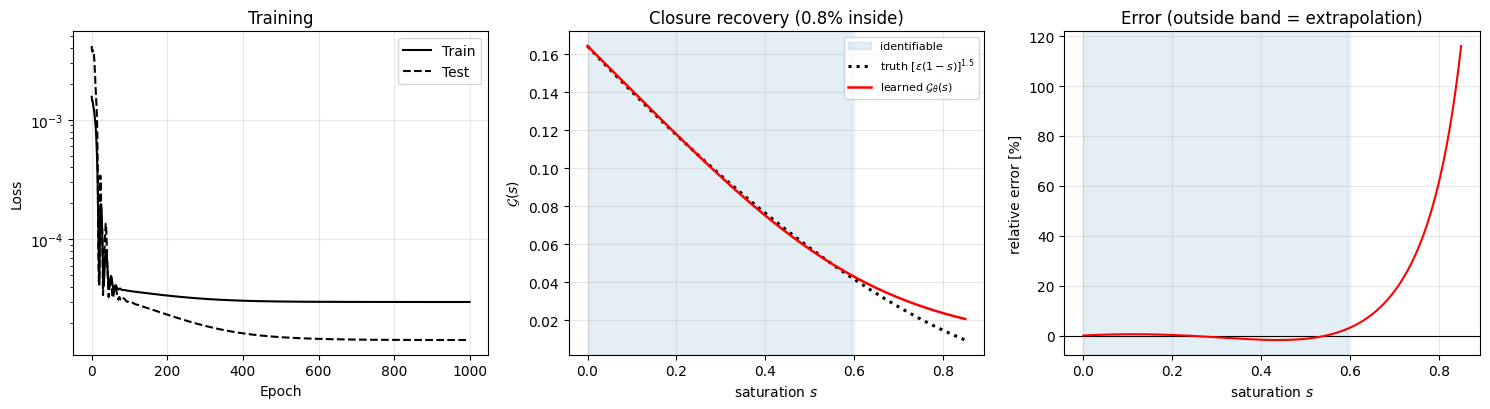

gradient check best |ratio-1| : 6.28e-08
identifiability interval      : s in [0.000, 0.595]


In [12]:
import numpy as np, matplotlib.pyplot as plt
d = np.load('/content/protoA_results/protoA.npz')

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].semilogy(d['train'], 'k-', label='Train')
ax[0].semilogy(d['test'], 'k--', label='Test')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].legend()
ax[0].set_title('Training'); ax[0].grid(alpha=.3)

s, gm, gg = d['s_plot'], d['G_ml'], d['G_gt']
lo, hi = float(d['S_LO']), float(d['S_HI'])
ax[1].axvspan(lo, hi, color='tab:blue', alpha=.12, label='identifiable')
ax[1].plot(s, gg, 'k:', lw=2.2, label=r'truth $[\varepsilon(1-s)]^{1.5}$')
ax[1].plot(s, gm, 'r-', lw=1.8, label=r'learned $\mathcal{G}_\theta(s)$')
ax[1].set_xlabel('saturation $s$'); ax[1].set_ylabel(r'$\mathcal{G}(s)$')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
ax[1].set_title(f"Closure recovery ({float(d['err_in']):.1f}% inside)")

rel = (gm-gg)/gg*100
ax[2].axvspan(lo, hi, color='tab:blue', alpha=.12)
ax[2].axhline(0, color='k', lw=.8)
ax[2].plot(s, rel, 'r-')
ax[2].set_xlabel('saturation $s$'); ax[2].set_ylabel('relative error [%]')
ax[2].set_title('Error (outside band = extrapolation)'); ax[2].grid(alpha=.3)

plt.tight_layout(); plt.show()
print(f"gradient check best |ratio-1| : {float(d['grad_check_best']):.2e}")
print(f"identifiability interval      : s in [{lo:.3f}, {hi:.3f}]")


## 판정 기준

| 항목 | 통과 | 실패 시 |
|---|---|---|
| **① 그래디언트 검증** | `\|ratio-1\|` 최소값 < 1e-3 | **학습 돌리지 말 것.** 부호·가중치·BC 행 처리 순으로 점검 |
| ② 학습 곡선 | train/test 모두 하강 | 식별성 문제 — $s$ 필드 다양성 부족 |
| ③ 구간 내 복원 | 수 % 이내 | 잡음 수준·격자 확인 |
| ④ 구간 밖 | **틀려도 정상** | 관측이 정보를 주지 않은 영역 (Bukshtynov 서베이 Def. 1) |

①의 `ratio`는 $h$가 중간 크기일 때 1 근처에서 **평평한 고원**을 만들어야 한다.
너무 작은 $h$에서는 반올림 오차로, 큰 $h$에서는 절단 오차로 벗어나는 것이 정상이다.

## 다음 단계

- **A2** — 막 경계에 Tafel을 넣어 비선형화. Newton이 필요해지고 $K_{corr}$이 부활한다.
- **B** — 3필드 mixed 확장. $s$가 다시 $C_w$의 함수가 되고 $\psi$ 서브필드 추출 문제가 생긴다.

A → A2 → B 순서가 각 단계마다 실패 원인을 하나씩만 추가한다.